<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/B00_FaceForensics_Descargar_y_Preparar_Subset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B00 — Descargar y preparar subset de FaceForensics++ para el Grupo B

Este notebook deja el flujo del piloto completamente reproducible y persistente.

Los videos de FaceForensics++ se descargan **directamente a Google Drive**, no a `/content`, para que permanezcan disponibles aunque termine o cambie la sesión de Colab.

Después de la descarga, el notebook:

1. identifica los pares `target_source`;
2. evita tratar las dos direcciones recíprocas como observaciones independientes;
3. selecciona 5 parejas reproducibles;
4. extrae un frame del target, source y fake de referencia;
5. guarda los frames y manifests en Drive.

El fake suministrado por FaceForensics++ se conserva como **referencia**. La prueba causal de supervivencia del watermark se realizará posteriormente mediante:

```text
target → TrustMark → face swap nuevo → decode
```


In [ ]:
# ============================================================
# CELDA 1
# Importaciones
# ============================================================

from pathlib import Path
import hashlib
import json
import random
import re
import subprocess
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

print("✓ Importaciones listas.")


✓ Importaciones listas.


In [ ]:
# ============================================================
# CELDA 2
# Montar Google Drive y definir ROOT
# ============================================================

try:
    from google.colab import drive

    drive.mount("/content/drive")

    ROOT = Path(
        "/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026"
    )

except Exception:
    ROOT = Path.cwd() / "Investigacion_Deepfake_Watermarking_2026"


ROOT.mkdir(parents=True, exist_ok=True)

print("ROOT:")
print(ROOT)


Mounted at /content/drive
ROOT:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026


In [ ]:
# ============================================================
# CELDA 3
# Configuración de FaceForensics++
# ============================================================

SOURCE_DATASET = "FaceForensics++"
MANIPULATION = "Deepfakes"
COMPRESSION = "c23"

N_DOWNLOAD_ORIGINAL = 10
N_DOWNLOAD_FAKE = 10

N_PAIRS = 5
SEED = 2026
FRAME_FRACTION = 0.50

SUBSET_NAME = "smoke_10"


# ------------------------------------------------------------
# Videos persistentes
# ------------------------------------------------------------

FF_RAW_ROOT = (
    ROOT
    / "datasets"
    / "faceforensics"
    / "raw"
    / COMPRESSION
)


# ------------------------------------------------------------
# Subset procesado
# ------------------------------------------------------------

DATA_ROOT = (
    ROOT
    / "datasets"
    / "faceforensics"
    / SUBSET_NAME
)

TARGET_DIR = DATA_ROOT / "target"
SOURCE_DIR = DATA_ROOT / "source"
FAKE_REFERENCE_DIR = DATA_ROOT / "fake_reference"
MANIFEST_DIR = DATA_ROOT / "manifests"

MANIFEST_PAIRS = MANIFEST_DIR / "manifest_pairs.csv"
MANIFEST_IMAGES = MANIFEST_DIR / "manifest_images.csv"
CONFIG_FILE = MANIFEST_DIR / "config.json"


for path in [
    FF_RAW_ROOT,
    TARGET_DIR,
    SOURCE_DIR,
    FAKE_REFERENCE_DIR,
    MANIFEST_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


print("============================================================")
print(" CONFIGURACIÓN")
print("============================================================")
print(f"Videos persistentes:\n  {FF_RAW_ROOT}")
print()
print(f"Subset procesado:\n  {DATA_ROOT}")


 CONFIGURACIÓN
Videos persistentes:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/raw/c23

Subset procesado:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/smoke_10


In [ ]:
# ============================================================
# CELDA 4
# Descargar el script oficial de FaceForensics++
# ============================================================

SCRIPT_PATH = Path("/content/faceforensics_download_v4.py")

if not SCRIPT_PATH.exists():

    subprocess.check_call([
        "wget",
        "-q",
        "-O",
        str(SCRIPT_PATH),
        "http://kaldir.vc.in.tum.de/faceforensics_download_v4.py",
    ])

print("Script:")
print(SCRIPT_PATH)
print("✓ Script disponible.")


Script:
/content/faceforensics_download_v4.py
✓ Script disponible.


## Descarga persistente

Las dos celdas siguientes descargan los videos directamente a:

```text
MyDrive/Investigacion_Deepfake_Watermarking_2026/
datasets/faceforensics/raw/c23/
```

Si ya se descargaron anteriormente, puedes omitir las celdas de descarga y continuar con la verificación.


In [ ]:
# ============================================================
# CELDA 5
# Descargar videos originales a Google Drive
# ============================================================

cmd_original = [
    sys.executable,
    str(SCRIPT_PATH),
    str(FF_RAW_ROOT),
    "-d", "original",
    "-c", COMPRESSION,
    "-t", "videos",
    "--num_videos", str(N_DOWNLOAD_ORIGINAL),
    "--server", "EU2",
]

print("Descargando originales...")
print("Destino:", FF_RAW_ROOT)
print()

result = subprocess.run(
    cmd_original,
    input="\n",
    text=True,
    capture_output=True,
)

if result.stdout:
    print(result.stdout)

if result.returncode != 0:
    print("ERROR DEL SCRIPT:")
    print(result.stderr if result.stderr else "(sin stderr)")
    raise RuntimeError(
        f"La descarga de originales terminó con código "
        f"{result.returncode}."
    )

print("✓ Descarga de originales completada.")


Descargando originales...
Destino: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/raw/c23

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/raw/c23/original_sequences/youtube/c23/videos

✓ Descarga de originales completada.


In [ ]:
# ============================================================
# CELDA 6
# Descargar Deepfakes a Google Drive
# ============================================================

cmd_fake = [
    sys.executable,
    str(SCRIPT_PATH),
    str(FF_RAW_ROOT),
    "-d", "Deepfakes",
    "-c", COMPRESSION,
    "-t", "videos",
    "--num_videos", str(N_DOWNLOAD_FAKE),
    "--server", "EU2",
]

print("Descargando Deepfakes...")
print("Destino:", FF_RAW_ROOT)
print()

result = subprocess.run(
    cmd_fake,
    input="\n",
    text=True,
    capture_output=True,
)

if result.stdout:
    print(result.stdout)

if result.returncode != 0:
    print("ERROR DEL SCRIPT:")
    print(result.stderr if result.stderr else "(sin stderr)")
    raise RuntimeError(
        f"La descarga de Deepfakes terminó con código "
        f"{result.returncode}."
    )

print("✓ Descarga de Deepfakes completada.")


Descargando Deepfakes...
Destino: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/raw/c23

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/raw/c23/manipulated_sequences/Deepfakes/c23/videos

✓ Descarga de Deepfakes completada.


In [ ]:
# ============================================================
# CELDA 7
# Localizar las carpetas descargadas
# ============================================================

ORIGINAL_DIR = (
    FF_RAW_ROOT
    / "original_sequences"
    / "youtube"
    / COMPRESSION
    / "videos"
)

FAKE_DIR = (
    FF_RAW_ROOT
    / "manipulated_sequences"
    / MANIPULATION
    / COMPRESSION
    / "videos"
)


assert ORIGINAL_DIR.exists(), (
    "No se encontró la carpeta de originales:\n"
    f"{ORIGINAL_DIR}"
)

assert FAKE_DIR.exists(), (
    "No se encontró la carpeta de Deepfakes:\n"
    f"{FAKE_DIR}"
)


original_files = sorted(
    ORIGINAL_DIR.glob("*.mp4")
)

fake_files = sorted(
    FAKE_DIR.glob("*.mp4")
)


print("============================================================")
print(" VIDEOS DISPONIBLES EN DRIVE")
print("============================================================")
print(f"Originales: {len(original_files)}")
print(f"Deepfakes:  {len(fake_files)}")
print()

for path in fake_files:
    print(" ", path.name)


 VIDEOS DISPONIBLES EN DRIVE
Originales: 10
Deepfakes:  10

  183_253.mp4
  253_183.mp4
  469_481.mp4
  481_469.mp4
  585_599.mp4
  599_585.mp4
  672_720.mp4
  720_672.mp4
  866_878.mp4
  878_866.mp4


In [ ]:
# ============================================================
# CELDA 8
# Interpretar target y source
# ============================================================

pattern = re.compile(
    r"^(.+?)_(.+?)\.mp4$"
)

rows = []

for fake_path in fake_files:

    match = pattern.match(
        fake_path.name
    )

    if match is None:
        continue

    target_id = match.group(1)
    source_id = match.group(2)

    target_video = (
        ORIGINAL_DIR
        / f"{target_id}.mp4"
    )

    source_video = (
        ORIGINAL_DIR
        / f"{source_id}.mp4"
    )

    rows.append({
        "fake_filename": fake_path.name,
        "fake_video": str(fake_path),
        "target_id": target_id,
        "source_id": source_id,
        "target_video": str(target_video),
        "source_video": str(source_video),
        "target_available": target_video.exists(),
        "source_available": source_video.exists(),
    })


pairs_available = pd.DataFrame(
    rows
)

assert len(pairs_available) > 0, (
    "No se encontraron manipulaciones con "
    "la forma target_source.mp4."
)

assert (
    pairs_available["target_available"].all()
), "Faltan algunos targets originales."

assert (
    pairs_available["source_available"].all()
), "Faltan algunos sources originales."


display(pairs_available)


,fake_filename,fake_video,target_id,source_id,target_video,source_video,target_available,source_available
0,183_253.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,183,253,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
1,253_183.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,253,183,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
2,469_481.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,469,481,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
3,481_469.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,481,469,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
4,585_599.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,585,599,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
5,599_585.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,599,585,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
6,672_720.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,672,720,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
7,720_672.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,720,672,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
8,866_878.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,866,878,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True
9,878_866.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,878,866,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,True,True


In [ ]:
# ============================================================
# CELDA 9
# Agrupar direcciones recíprocas
# ============================================================

def canonical_identity_pair(
    target_id,
    source_id,
):

    try:
        values = sorted(
            [target_id, source_id],
            key=lambda x: int(x),
        )
    except ValueError:
        values = sorted(
            [target_id, source_id]
        )

    return (
        f"{values[0]}__{values[1]}"
    )


pairs_available[
    "identity_pair"
] = pairs_available.apply(
    lambda row: canonical_identity_pair(
        row["target_id"],
        row["source_id"],
    ),
    axis=1,
)


identity_groups = sorted(
    pairs_available[
        "identity_pair"
    ]
    .unique()
    .tolist()
)


print("Parejas de identidades:")
print()

for identity_pair in identity_groups:

    group = pairs_available[
        pairs_available[
            "identity_pair"
        ] == identity_pair
    ]

    directions = ", ".join(
        sorted(
            group[
                "fake_filename"
            ].tolist()
        )
    )

    print(
        f"{identity_pair}: "
        f"{directions}"
    )


assert len(identity_groups) >= N_PAIRS, (
    f"Se requieren {N_PAIRS} parejas "
    f"y se encontraron {len(identity_groups)}."
)


Parejas de identidades:

183__253: 183_253.mp4, 253_183.mp4
469__481: 469_481.mp4, 481_469.mp4
585__599: 585_599.mp4, 599_585.mp4
672__720: 672_720.mp4, 720_672.mp4
866__878: 866_878.mp4, 878_866.mp4


In [ ]:
# ============================================================
# CELDA 10
# Selección reproducible
# ============================================================

rng = random.Random(
    SEED
)

selected_identity_pairs = sorted(
    rng.sample(
        identity_groups,
        N_PAIRS,
    )
)

selected_rows = []

for identity_pair in selected_identity_pairs:

    group = (
        pairs_available[
            pairs_available[
                "identity_pair"
            ] == identity_pair
        ]
        .sort_values(
            "fake_filename"
        )
        .reset_index(
            drop=True
        )
    )

    selected_index = rng.randrange(
        len(group)
    )

    selected_rows.append(
        group.iloc[
            selected_index
        ].to_dict()
    )


selected_pairs = pd.DataFrame(
    selected_rows
)

selected_pairs.insert(
    0,
    "pair_index",
    range(
        1,
        len(selected_pairs) + 1,
    ),
)

selected_pairs.insert(
    1,
    "pair_id",
    [
        f"pair_{i:03d}"
        for i in range(
            1,
            len(selected_pairs) + 1,
        )
    ],
)


display(
    selected_pairs[
        [
            "pair_id",
            "identity_pair",
            "target_id",
            "source_id",
            "fake_filename",
        ]
    ]
)


,pair_id,identity_pair,target_id,source_id,fake_filename
0,pair_001,183__253,253,183,253_183.mp4
1,pair_002,469__481,481,469,481_469.mp4
2,pair_003,585__599,599,585,599_585.mp4
3,pair_004,672__720,672,720,672_720.mp4
4,pair_005,866__878,866,878,866_878.mp4


In [ ]:
# ============================================================
# CELDA 11
# Funciones para extraer frames
# ============================================================

def extract_frame_at_fraction(
    video_path,
    fraction=0.50,
):

    cap = cv2.VideoCapture(
        str(video_path)
    )

    if not cap.isOpened():
        raise RuntimeError(
            f"No se pudo abrir: "
            f"{video_path}"
        )

    frame_count = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )

    fps = float(
        cap.get(
            cv2.CAP_PROP_FPS
        )
    )

    if frame_count <= 0:
        cap.release()
        raise RuntimeError(
            f"Frame count inválido: "
            f"{video_path}"
        )

    frame_index = int(
        round(
            (frame_count - 1)
            * fraction
        )
    )

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_index,
    )

    ok, frame_bgr = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(
            f"No se pudo leer "
            f"frame {frame_index}: "
            f"{video_path}"
        )

    frame_rgb = cv2.cvtColor(
        frame_bgr,
        cv2.COLOR_BGR2RGB,
    )

    return {
        "image": frame_rgb,
        "frame_index": frame_index,
        "frame_count": frame_count,
        "fps": fps,
        "width": int(
            frame_rgb.shape[1]
        ),
        "height": int(
            frame_rgb.shape[0]
        ),
    }


def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()


In [ ]:
# ============================================================
# CELDA 12
# Extraer frames y construir manifests
# ============================================================

pair_records = []
image_records = []

for row in selected_pairs.itertuples(
    index=False
):

    pair_id = row.pair_id

    target_data = extract_frame_at_fraction(
        row.target_video,
        FRAME_FRACTION,
    )

    source_data = extract_frame_at_fraction(
        row.source_video,
        FRAME_FRACTION,
    )

    fake_data = extract_frame_at_fraction(
        row.fake_video,
        FRAME_FRACTION,
    )


    target_path = (
        TARGET_DIR
        / f"{pair_id}_target.png"
    )

    source_path = (
        SOURCE_DIR
        / f"{pair_id}_source.png"
    )

    fake_path = (
        FAKE_REFERENCE_DIR
        / f"{pair_id}_fake_reference.png"
    )


    Image.fromarray(
        target_data["image"]
    ).save(
        target_path
    )

    Image.fromarray(
        source_data["image"]
    ).save(
        source_path
    )

    Image.fromarray(
        fake_data["image"]
    ).save(
        fake_path
    )


    pair_records.append({
        "pair_index": row.pair_index,
        "pair_id": pair_id,
        "identity_pair": row.identity_pair,
        "target_id": row.target_id,
        "source_id": row.source_id,
        "target_video": row.target_video,
        "source_video": row.source_video,
        "fake_reference_video": row.fake_video,
        "fake_reference_filename": row.fake_filename,
        "target_frame": str(target_path),
        "source_frame": str(source_path),
        "fake_reference_frame": str(fake_path),
        "frame_fraction": FRAME_FRACTION,
        "target_frame_index": target_data["frame_index"],
        "source_frame_index": source_data["frame_index"],
        "fake_frame_index": fake_data["frame_index"],
        "source_dataset": SOURCE_DATASET,
        "manipulation": MANIPULATION,
        "compression": COMPRESSION,
        "seed": SEED,
    })


    for role, label, path, data in [
        (
            "target",
            "real",
            target_path,
            target_data,
        ),
        (
            "source",
            "real",
            source_path,
            source_data,
        ),
        (
            "fake_reference",
            "fake",
            fake_path,
            fake_data,
        ),
    ]:

        image_records.append({
            "pair_index": row.pair_index,
            "pair_id": pair_id,
            "identity_pair": row.identity_pair,
            "role": role,
            "class_label": label,
            "filename": path.name,
            "filepath": str(path),
            "width": data["width"],
            "height": data["height"],
            "sha256": sha256_file(
                path
            ),
            "source_dataset": SOURCE_DATASET,
            "manipulation": MANIPULATION,
            "compression": COMPRESSION,
            "seed": SEED,
        })


manifest_pairs = pd.DataFrame(
    pair_records
)

manifest_images = pd.DataFrame(
    image_records
)


display(manifest_pairs)
display(manifest_images)


,pair_index,pair_id,identity_pair,target_id,source_id,target_video,source_video,fake_reference_video,fake_reference_filename,target_frame,source_frame,fake_reference_frame,frame_fraction,target_frame_index,source_frame_index,fake_frame_index,source_dataset,manipulation,compression,seed
0,1,pair_001,183__253,253,183,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,253_183.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,0.5,250,194,250,FaceForensics++,Deepfakes,c23,2026
1,2,pair_002,469__481,481,469,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,481_469.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,0.5,206,206,206,FaceForensics++,Deepfakes,c23,2026
2,3,pair_003,585__599,599,585,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,599_585.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,0.5,198,179,198,FaceForensics++,Deepfakes,c23,2026
3,4,pair_004,672__720,672,720,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,672_720.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,0.5,270,282,270,FaceForensics++,Deepfakes,c23,2026
4,5,pair_005,866__878,866,878,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,866_878.mp4,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,0.5,254,368,254,FaceForensics++,Deepfakes,c23,2026


,pair_index,pair_id,identity_pair,role,class_label,filename,filepath,width,height,sha256,source_dataset,manipulation,compression,seed
0,1,pair_001,183__253,target,real,pair_001_target.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,5fea2e89b1cbabde35c5d1dcb0164cbf402773f35f0abb...,FaceForensics++,Deepfakes,c23,2026
1,1,pair_001,183__253,source,real,pair_001_source.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,0d256b4a4daafdd3d9e75af5ea84fe2af4b1de3adedcc8...,FaceForensics++,Deepfakes,c23,2026
2,1,pair_001,183__253,fake_reference,fake,pair_001_fake_reference.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,a45c03ed3c903dba16f275036c132c288731a623c11000...,FaceForensics++,Deepfakes,c23,2026
3,2,pair_002,469__481,target,real,pair_002_target.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,e8b35020cf86a5113b33ed4104fee43e3a14ab13942ff9...,FaceForensics++,Deepfakes,c23,2026
4,2,pair_002,469__481,source,real,pair_002_source.png,/content/drive/MyDrive/Investigacion_Deepfake_...,854,480,4645c6d5c700448d06ca30ee724be80da6f158f56dcf0c...,FaceForensics++,Deepfakes,c23,2026
5,2,pair_002,469__481,fake_reference,fake,pair_002_fake_reference.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,5a4426e32c31a1b68ac1392ea9fa6a40749e250231cefd...,FaceForensics++,Deepfakes,c23,2026
6,3,pair_003,585__599,target,real,pair_003_target.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,06178b394ffef44296b7911da3c3c4339ba454daf9946d...,FaceForensics++,Deepfakes,c23,2026
7,3,pair_003,585__599,source,real,pair_003_source.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,87286699ebcf3b6a220f5f278728cd84114b1c1c5dbaf0...,FaceForensics++,Deepfakes,c23,2026
8,3,pair_003,585__599,fake_reference,fake,pair_003_fake_reference.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,aa2b292ca8c3b54e53d4e499bbbebf3e6d69db0675d486...,FaceForensics++,Deepfakes,c23,2026
9,4,pair_004,672__720,target,real,pair_004_target.png,/content/drive/MyDrive/Investigacion_Deepfake_...,1280,720,7dc34d8c60fe848fd2e367f403cc748d92101529d9171d...,FaceForensics++,Deepfakes,c23,2026


In [ ]:
# ============================================================
# CELDA 13
# Validar y guardar
# ============================================================

assert len(
    manifest_pairs
) == N_PAIRS

assert (
    manifest_pairs[
        "identity_pair"
    ].nunique()
    == N_PAIRS
)

assert len(
    manifest_images
) == 3 * N_PAIRS

assert (
    manifest_images[
        "sha256"
    ].nunique()
    == 3 * N_PAIRS
)


manifest_pairs.to_csv(
    MANIFEST_PAIRS,
    index=False,
)

manifest_images.to_csv(
    MANIFEST_IMAGES,
    index=False,
)


config = {
    "group": "B",
    "source_dataset": SOURCE_DATASET,
    "manipulation": MANIPULATION,
    "compression": COMPRESSION,
    "subset": SUBSET_NAME,
    "raw_video_root": str(
        FF_RAW_ROOT
    ),
    "n_pairs": N_PAIRS,
    "n_saved_frames": 3 * N_PAIRS,
    "frame_fraction": FRAME_FRACTION,
    "seed": SEED,
    "pairing_rule": (
        "one directed manipulation "
        "per unordered identity pair"
    ),
    "selected_pairs": (
        manifest_pairs[
            [
                "pair_id",
                "target_id",
                "source_id",
                "fake_reference_filename",
            ]
        ]
        .to_dict(
            orient="records"
        )
    ),
}


with open(
    CONFIG_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        config,
        f,
        indent=2,
        ensure_ascii=False,
    )


print("✓ Subset validado y guardado.")
print()
print("Videos persistentes:")
print(FF_RAW_ROOT)
print()
print("Manifest pares:")
print(MANIFEST_PAIRS)
print()
print("Manifest imágenes:")
print(MANIFEST_IMAGES)


✓ Subset validado y guardado.

Videos persistentes:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/raw/c23

Manifest pares:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/smoke_10/manifests/manifest_pairs.csv

Manifest imágenes:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/smoke_10/manifests/manifest_images.csv


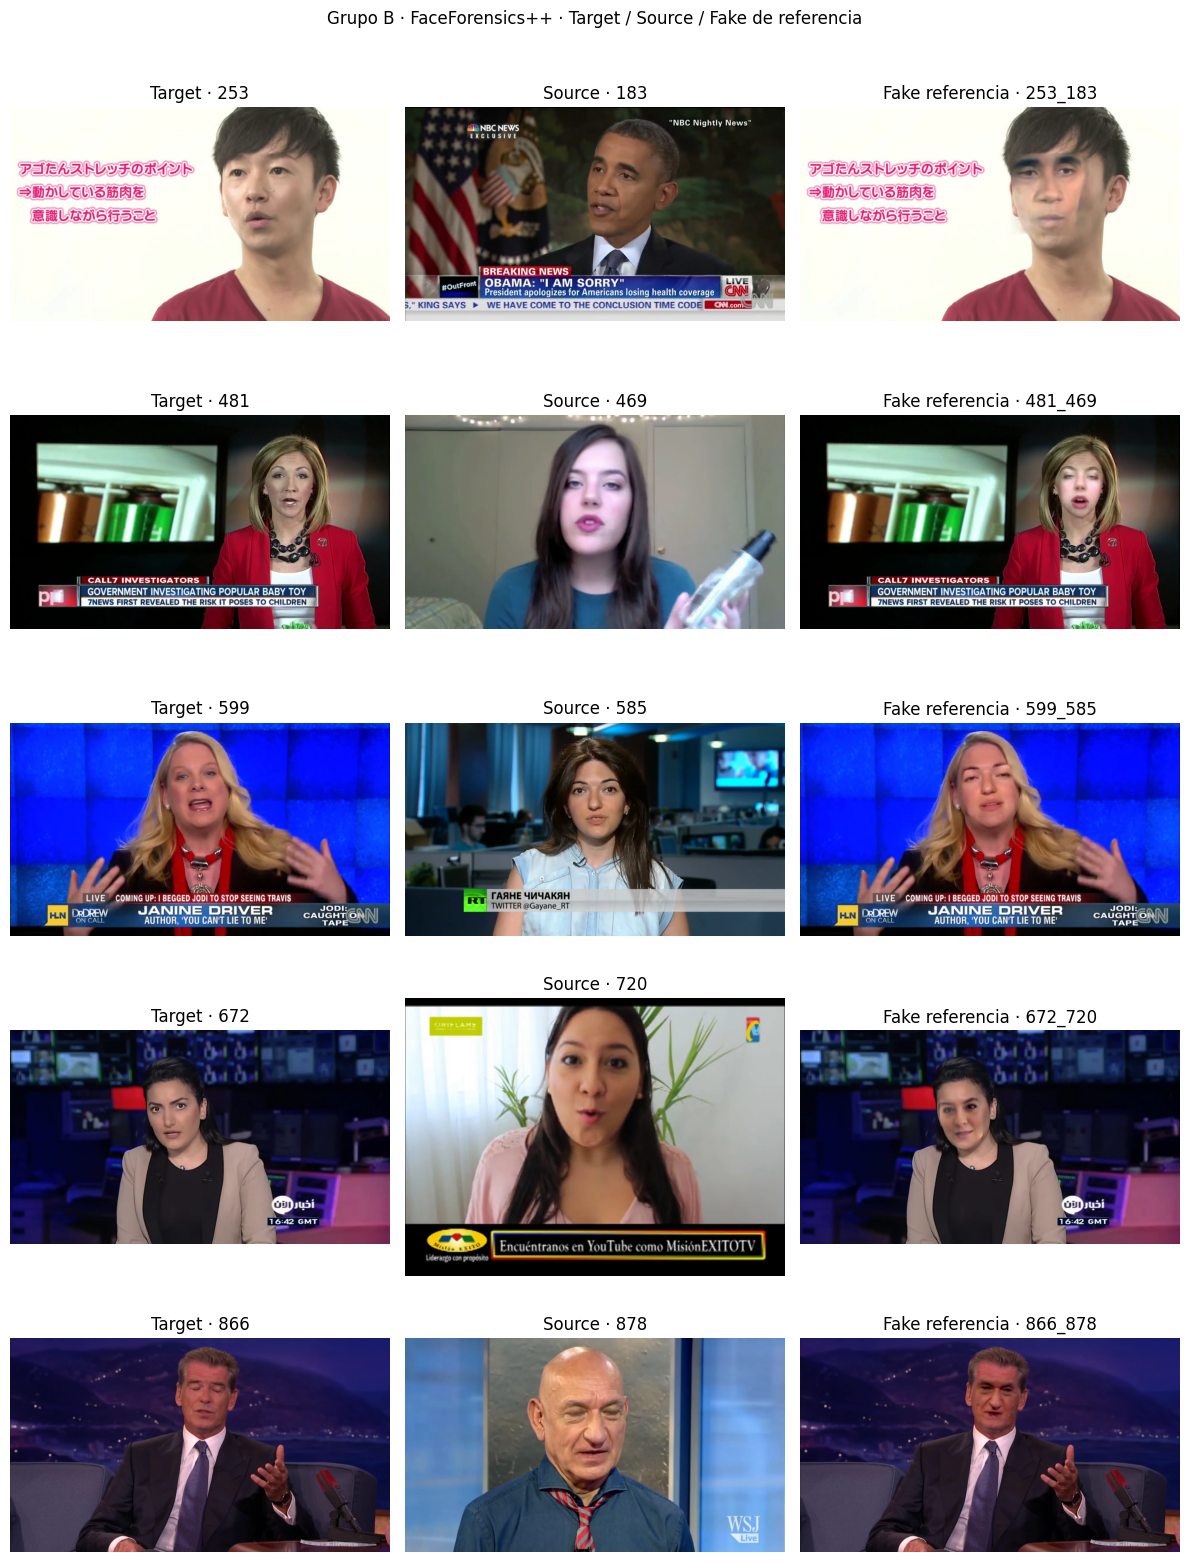

In [ ]:
# ============================================================
# CELDA 14
# Visualización
# ============================================================

fig, axes = plt.subplots(
    N_PAIRS,
    3,
    figsize=(
        12,
        3.2 * N_PAIRS,
    ),
)

if N_PAIRS == 1:
    axes = np.array(
        [axes]
    )


for i, row in manifest_pairs.iterrows():

    paths = [
        Path(
            row["target_frame"]
        ),
        Path(
            row["source_frame"]
        ),
        Path(
            row[
                "fake_reference_frame"
            ]
        ),
    ]

    titles = [
        f"Target · "
        f"{row['target_id']}",

        f"Source · "
        f"{row['source_id']}",

        f"Fake referencia · "
        f"{row['target_id']}_"
        f"{row['source_id']}",
    ]


    for j, (
        path,
        title,
    ) in enumerate(
        zip(
            paths,
            titles,
        )
    ):

        with Image.open(
            path
        ) as img:

            image = (
                img
                .convert("RGB")
                .copy()
            )

        axes[
            i,
            j,
        ].imshow(
            image
        )

        axes[
            i,
            j,
        ].set_title(
            title
        )

        axes[
            i,
            j,
        ].axis(
            "off"
        )


plt.suptitle(
    "Grupo B · FaceForensics++ · "
    "Target / Source / Fake de referencia",
    y=1.002,
)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CELDA 15
# Resumen
# ============================================================

print("============================================================")
print(" B00 COMPLETADO")
print("============================================================")
print()
print("Los videos originales y Deepfakes están")
print("guardados persistentemente en Google Drive.")
print()
print(f"Pares seleccionados: {N_PAIRS}")
print(f"Frames guardados:    {3 * N_PAIRS}")
print()
print("Siguiente etapa:")
print()
print(
    "target → TrustMark → "
    "face swap → decode"
)


 B00 COMPLETADO

Los videos originales y Deepfakes están
guardados persistentemente en Google Drive.

Pares seleccionados: 5
Frames guardados:    15

Siguiente etapa:

target → TrustMark → face swap → decode
